<a href="https://colab.research.google.com/github/kurniarahmi/Sales-Revenue-Analysis/blob/main/python/Sales_%26_Revenue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-cloud-bigquery pandas matplotlib seaborn

In [2]:
pip install pyarrow

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import bigquery
import pandas as pd
client = bigquery.Client(project='fair-hallway-256512')

## Dataset yang digunakan

In [5]:
query = """
SELECT
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.sale_price,
  oi.created_at,
  u.country,
  p.name
FROM
  bigquery-public-data.thelook_ecommerce.order_items oi
JOIN
  bigquery-public-data.thelook_ecommerce.users u
ON
  oi.user_id = u.id
JOIN
  bigquery-public-data.thelook_ecommerce.products p
ON
  oi.product_id = p.id
"""

df = client.query(query).to_dataframe()

In [6]:
df

,order_id,user_id,product_id,sale_price,created_at,country,name
0,21265,16855,13659,1.82,2025-09-18 01:48:11+00:00,Poland,Blank Long Cuff Beanie Cap (Choose Many Colors...
1,79608,63382,12580,3.37,2026-04-13 16:11:45.821310+00:00,Poland,Allegra K 5 Pcs Bra Black 2x3 Hooks Extenders ...
2,56557,45013,13943,3.40,2021-11-20 18:07:11+00:00,Poland,Blues Brothers Wayfarer Dark Black Sun Glasses...
3,50333,39939,28406,3.46,2026-03-15 05:03:20+00:00,Poland,Extra Warm Metro Fleece Ear Warmers
4,58363,46422,28406,3.46,2026-04-15 12:10:24.301882+00:00,Poland,Extra Warm Metro Fleece Ear Warmers
...,...,...,...,...,...,...,...
181774,106666,85059,24341,950.00,2025-10-29 05:17:26+00:00,United States,Nobis Yatesy Parka
181775,107118,85444,24110,990.00,2026-01-26 00:01:33+00:00,United States,Woolrich Arctic Parka DF
181776,36738,29199,24447,999.00,2025-02-02 04:46:23+00:00,United States,Darla
181777,35543,28215,23546,999.00,2024-04-04 15:40:41+00:00,United States,Alpha Industries Rip Stop Short


## Cleaning Data

In [7]:
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.dropna()

In [8]:
df['month'] = df['created_at'].dt.to_period('M')

/tmp/ipykernel_1686/4241509362.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_at'].dt.to_period('M')
/tmp/ipykernel_1686/4241509362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['created_at'].dt.to_period('M')


#Exploratory Data Analysis (EDA)

## Revenue Trend

<Axes: xlabel='month'>

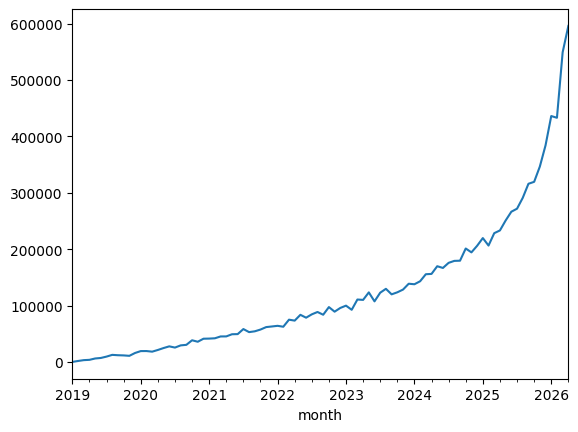

In [9]:
monthly_revenue = df.groupby('month')['sale_price'].sum()
monthly_revenue.plot()

* Revenue menunjukkan tren naik konsisten tanpa penurunan signifikan
* Di periode akhir terlihat akselerasi growth (makin cepat naik)
* Volatilitas rendah → bisnis relatif stabil
* Belum ada tanda plateau → masih ada potensi growth lebih lanjut

##Top Product Contribution

In [10]:
top_products = df.groupby('name')['sale_price'].sum().sort_values(ascending=False).head(10)

In [11]:
top_products

,sale_price
name,
Canada Goose Men's The Chateau Jacket,13855.00000
Woolrich Arctic Parka DF,11880.00000
NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outstanding Support and Comfort*,11739.00000
The North Face Apex Bionic Soft Shell Jacket - Men's,11739.00000
True Religion Men's Ricky Straight Jean,10589.55011
The North Face Denali Down Womens Jacket 2013,9933.00000
Nike Jordan Retro 11 Bred Bootie Socks,9030.00000
Canada Goose Men's Citadel Parka,8745.00000
The North Face Apex Bionic Jacket - Men's,8127.00000


* Revenue didominasi oleh produk premium (outerwear & brand besar) → kontribusi tinggi meskipun jumlah produk sedikit
* Top products menunjukkan pola high-value, low-volume (harga tinggi jadi driver utama revenue)
* Ada sedikit variasi (jeans, shorts), tapi tetap kalah kontribusi dibanding jacket premium

In [12]:
worst_products = df.groupby('name')['sale_price'].sum().sort_values(ascending=True).head(10)
worst_products

,sale_price
name,
Indestructable Aluminum Aluma Wallet - RED,0.06
Wool Arctic Socks,2.99
Alivila.Y Fashion Sexy Lace Lingerie Sleepwear Sleep Dress Set With G-String 402,2.99
Set of 2 - Replacement Insert For Checkbook Wallets Card Or Picture Insert,3.43
Pink Ribbon Breast Cancer Awareness Knee High Socks Great for Sports Teams Fundraising Relay for Life Walk Survivor (Style 21),3.90
GENUINE LEATHER SNAP ON STUDDED WHITE PIANO BELT FITS ANY BUCKLE,4.50
Solid Color Leather Adjustable Skinny Belt with,4.53
Braza Magic Clip (4400),5.93
Allegra K Ladies Waist Flower Print Stretch Short Beach Shorts,6.61


* Worst products punya revenue sangat kecil → indikasi low price, low impact, bahkan berpotensi tidak profitable
* Terdapat long-tail distribution → sebagian kecil produk menyumbang mayoritas revenue

##Customer Value Analysis

In [13]:
customer_value = df.groupby('user_id')['sale_price'].sum()
customer_value.describe()

,sale_price
count,80072.000000
mean,135.429130
std,138.197720
min,0.490000
25%,42.000000
50%,89.989998
75%,181.822499
max,1913.989998


* Distribusi nilai transaksi menunjukkan right-skewed (condong ke kanan) → sebagian besar transaksi bernilai rendah, tapi ada sedikit transaksi dengan nilai sangat tinggi (max 1936)
* Median (89) jauh lebih rendah dari mean (134) → menandakan outlier high-value cukup signifikan dan mendorong rata-rata naik
50% transaksi berada di range 41 – 180 → ini adalah core spending customer (mid-range)
* Adanya nilai minimum sangat kecil (0.02) → indikasi anomali data atau diskon ekstrem

👉 mayoritas customer belanja di level rendah–menengah, tapi revenue sangat dipengaruhi oleh transaksi high-value (premium segment)

#Deep Analysis

##RFM Analysis

In [14]:
import datetime as dt

snapshot_date = df['created_at'].max()

rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']


In [15]:
rfm

,recency,frequency,monetary
user_id,,,
1,114,1,32.500000
2,235,1,17.389999
4,590,1,79.000000
5,2,2,151.389999
7,52,2,75.000000
...,...,...,...
99996,137,2,134.500000
99997,306,1,25.000000
99998,433,1,269.000000


## Distribusi RFM (Recency, Frequency, Monetary)

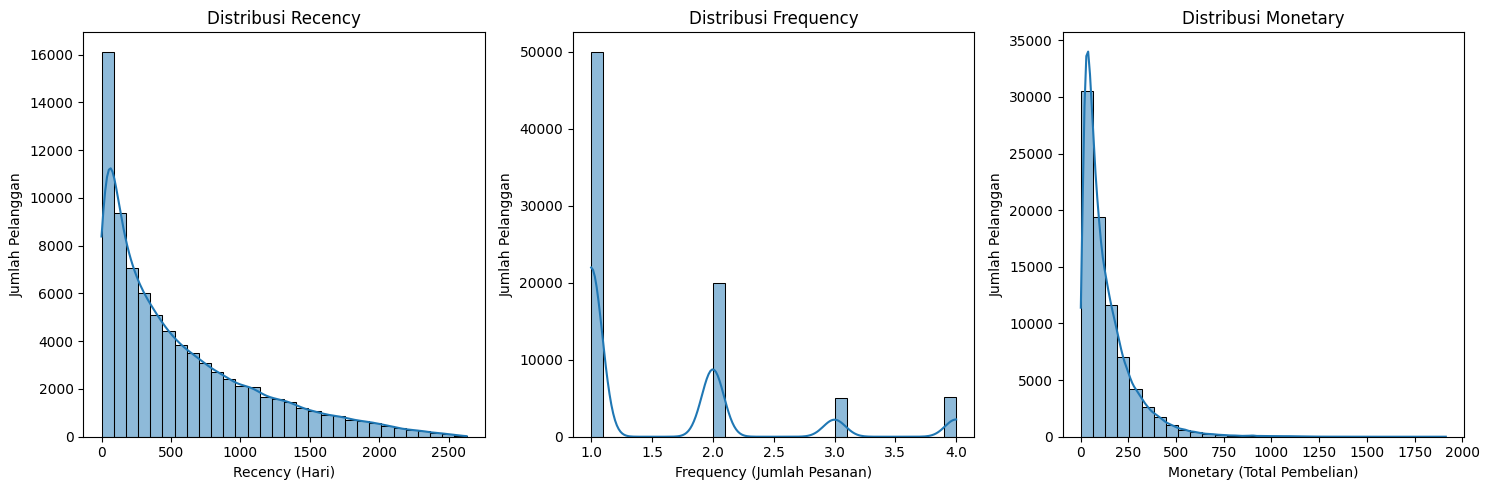

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Recency distribution
plt.subplot(1, 3, 1)
sns.histplot(rfm['recency'], bins=30, kde=True)
plt.title('Distribusi Recency')
plt.xlabel('Recency (Hari)')
plt.ylabel('Jumlah Pelanggan')

# Frequency distribution
plt.subplot(1, 3, 2)
sns.histplot(rfm['frequency'], bins=30, kde=True)
plt.title('Distribusi Frequency')
plt.xlabel('Frequency (Jumlah Pesanan)')
plt.ylabel('Jumlah Pelanggan')

# Monetary distribution
plt.subplot(1, 3, 3)
sns.histplot(rfm['monetary'], bins=30, kde=True)
plt.title('Distribusi Monetary')
plt.xlabel('Monetary (Total Pembelian)')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

* Recency: Distribusi condong ke kanan → banyak customer sudah lama tidak bertransaksi → indikasi churn cukup tinggi / engagement menurun
* Frequency: Mayoritas customer hanya melakukan 1–2 transaksi → menunjukkan repeat rate masih rendah
* Monetary: Distribusi sangat skewed → sebagian besar customer spend kecil, hanya sedikit yang high-value

Singkatnya:
Customer base didominasi oleh low engagement (jarang beli & sudah lama tidak aktif). Sementara, Revenue kemungkinan besar ditopang oleh segelintir customer yang sering dan belanja besar dan ada peluang besar di retention & increasing purchase frequency

## Cohort Analysis

### Retention per Cohort (Yearly)

In [17]:
df['order_year'] = df['created_at'].dt.to_period('Y')
df['cohort'] = df.groupby('user_id')['order_year'].transform('min')

cohort_data = df.groupby(['cohort', 'order_year'])['user_id'].nunique().reset_index()

/tmp/ipykernel_1686/769042606.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['order_year'] = df['created_at'].dt.to_period('Y')
/tmp/ipykernel_1686/769042606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_year'] = df['created_at'].dt.to_period('Y')
/tmp/ipykernel_1686/769042606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cohort'] = df.groupby('user_id')['order_year'].transform('min')


In [18]:
cohort_data

,cohort,order_year,user_id
0,2019,2019,1081
1,2019,2020,159
2,2019,2021,138
3,2019,2022,167
4,2019,2023,139
5,2019,2024,151
6,2019,2025,149
7,2019,2026,41
8,2020,2020,3495
9,2020,2021,534


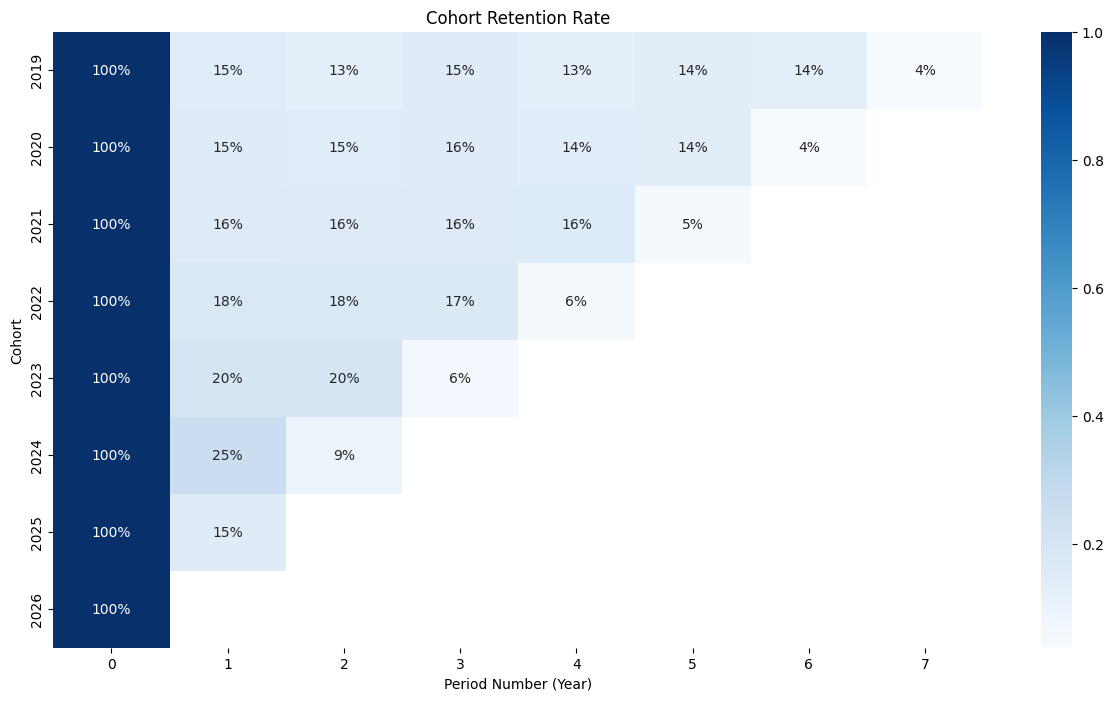

In [19]:
cohort_data['period_number'] = (cohort_data.order_year - cohort_data.cohort).apply(lambda x: x.n)

cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period_number', values='user_id')

cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='Blues')
plt.title('Cohort Retention Rate')
plt.xlabel('Period Number (Year)')
plt.ylabel('Cohort')
plt.show()

* Retention rate turun drastis setelah periode pertama → dari 100% ke ~15–26% di tahun berikutnya → indikasi drop-off tinggi setelah pembelian awal
* Setelah tahun ke-2/ke-3, retention makin menurun hingga <10% → sangat sedikit customer yang bertahan jangka panjang
* Cohort yang lebih baru (2023–2024) sempat menunjukkan retention awal lebih tinggi (~21–26%), tapi tetap turun cepat di periode berikutnya
* Pola ini konsisten di hampir semua cohort → menunjukkan masalah struktural di retention, bukan kasus tertentu

### Retention per Cohort (Monthly per Year)


--- Cohort Analysis for Year: 2019 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


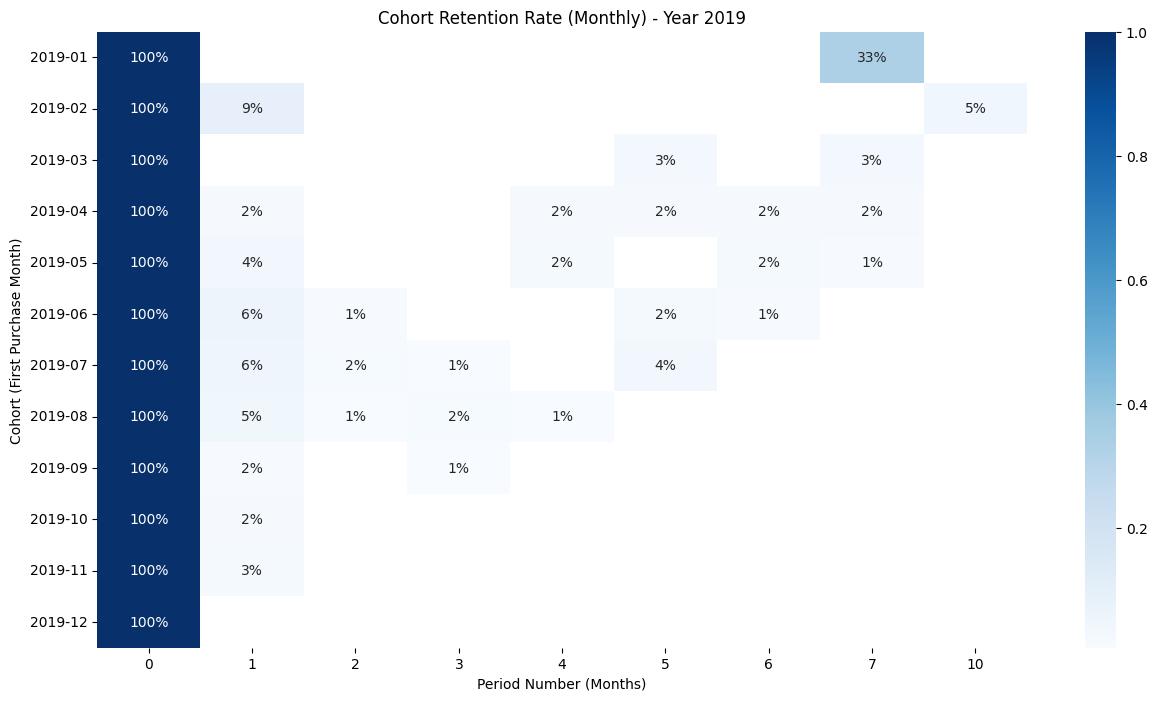


--- Cohort Analysis for Year: 2020 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


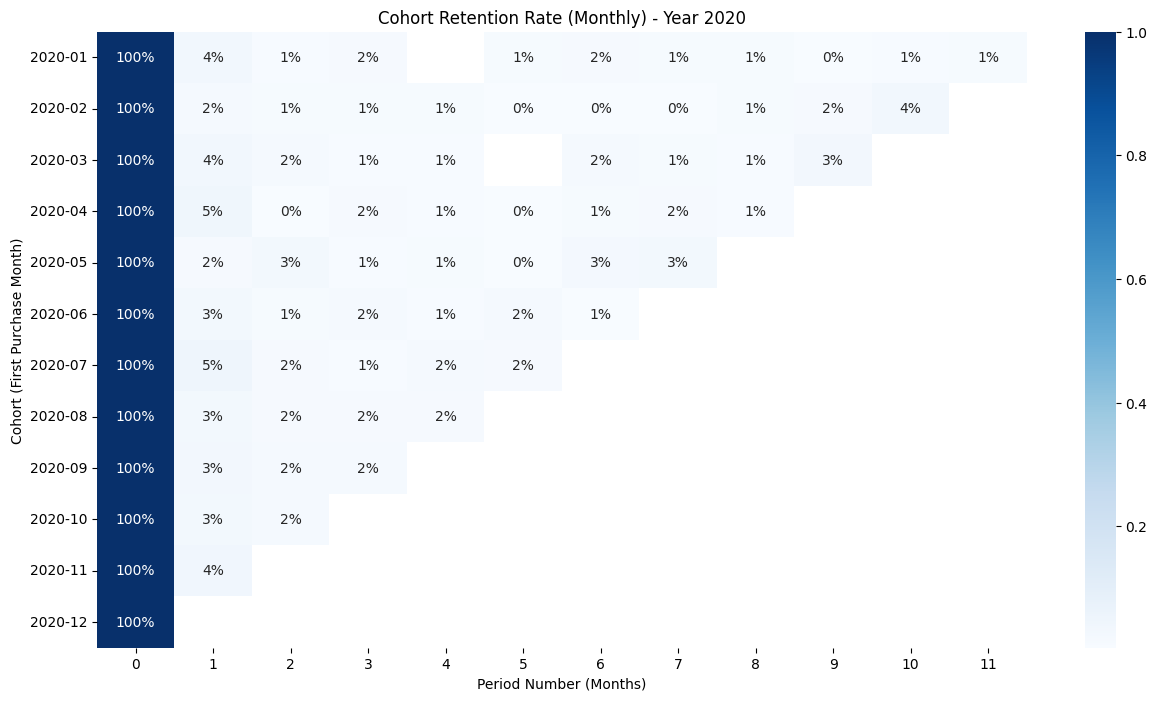


--- Cohort Analysis for Year: 2021 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


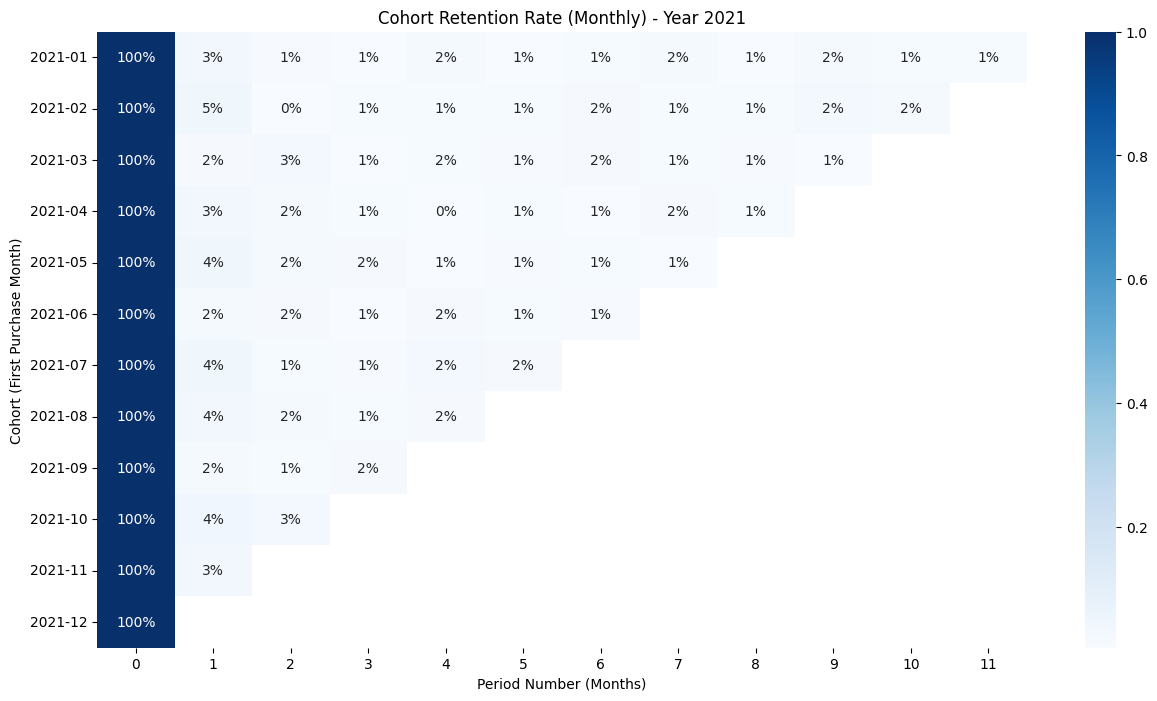


--- Cohort Analysis for Year: 2022 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


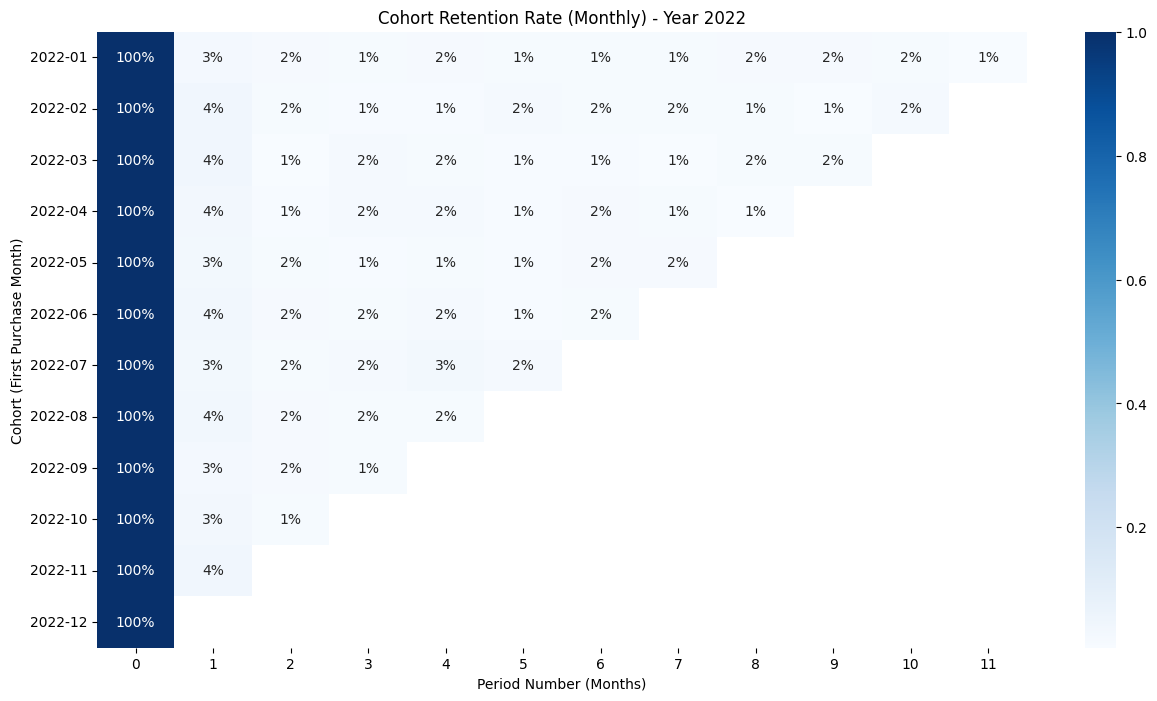


--- Cohort Analysis for Year: 2023 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


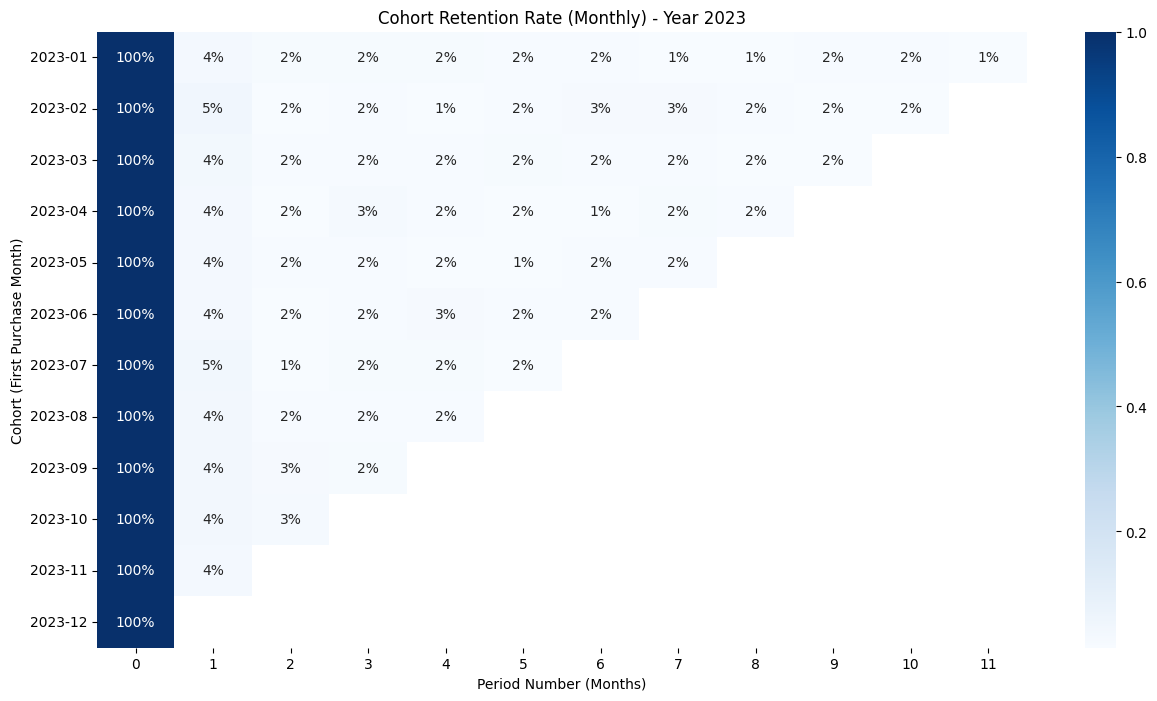


--- Cohort Analysis for Year: 2024 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


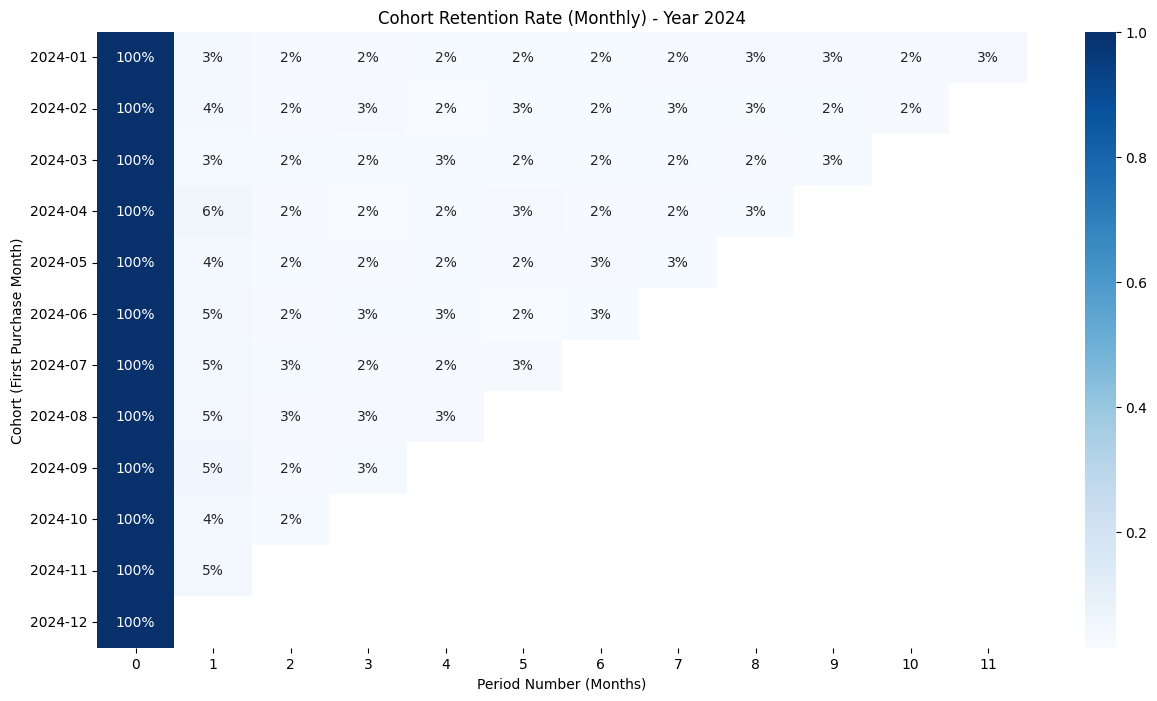


--- Cohort Analysis for Year: 2025 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


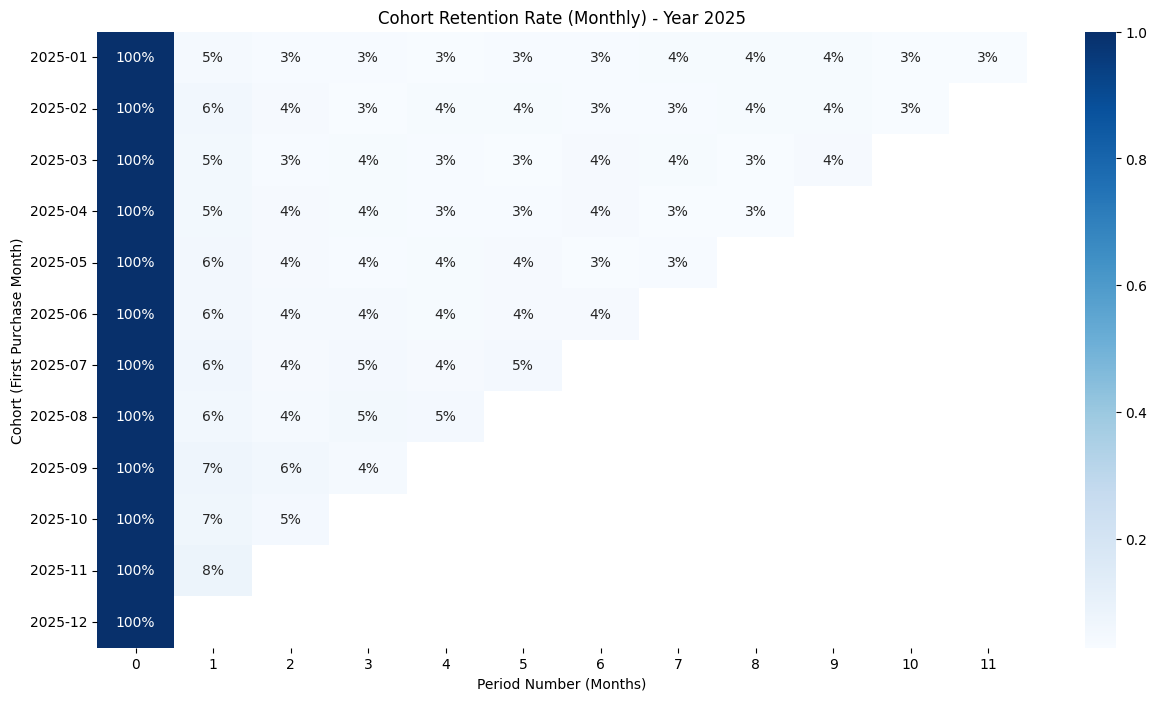


--- Cohort Analysis for Year: 2026 ---


/tmp/ipykernel_1686/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


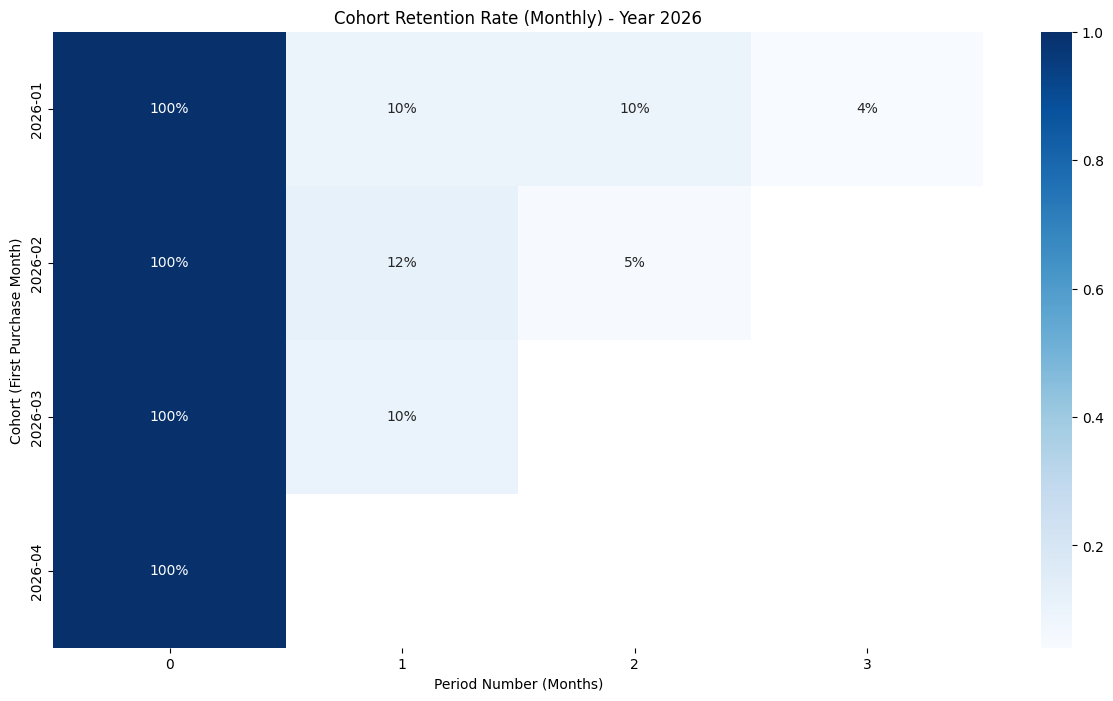

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique years from the DataFrame
all_years = sorted(df['created_at'].dt.year.unique())

for year in all_years:
    print(f"\n--- Cohort Analysis for Year: {year} ---")

    # Filter data for the current year
    df_year = df[df['created_at'].dt.year == year].copy()

    if df_year.empty:
        print(f"No data for year {year}, skipping.")
        continue

    # Define order_month and cohort for the current year
    df_year['order_month'] = df_year['created_at'].dt.to_period('M')
    df_year['cohort'] = df_year.groupby('user_id')['order_month'].transform('min')

    # Aggregate cohort data
    cohort_data_yearly = df_year.groupby(['cohort', 'order_month'])['user_id'].nunique().reset_index()

    # Calculate period number
    cohort_data_yearly['period_number'] = (cohort_data_yearly.order_month - cohort_data_yearly.cohort).apply(lambda x: x.n)

    # Create pivot table
    cohort_pivot_yearly = cohort_data_yearly.pivot_table(index='cohort', columns='period_number', values='user_id')

    # Calculate retention matrix
    cohort_sizes_yearly = cohort_pivot_yearly.iloc[:,0]
    retention_matrix_yearly = cohort_pivot_yearly.divide(cohort_sizes_yearly, axis=0)

    # Plot heatmap
    plt.figure(figsize=(15, 8))
    sns.heatmap(retention_matrix_yearly, annot=True, fmt='.0%', cmap='Blues')
    plt.title(f'Cohort Retention Rate (Monthly) - Year {year}')
    plt.xlabel('Period Number (Months)')
    plt.ylabel('Cohort (First Purchase Month)')
    plt.show()


### Churn Rate per Cohort (Yearly)

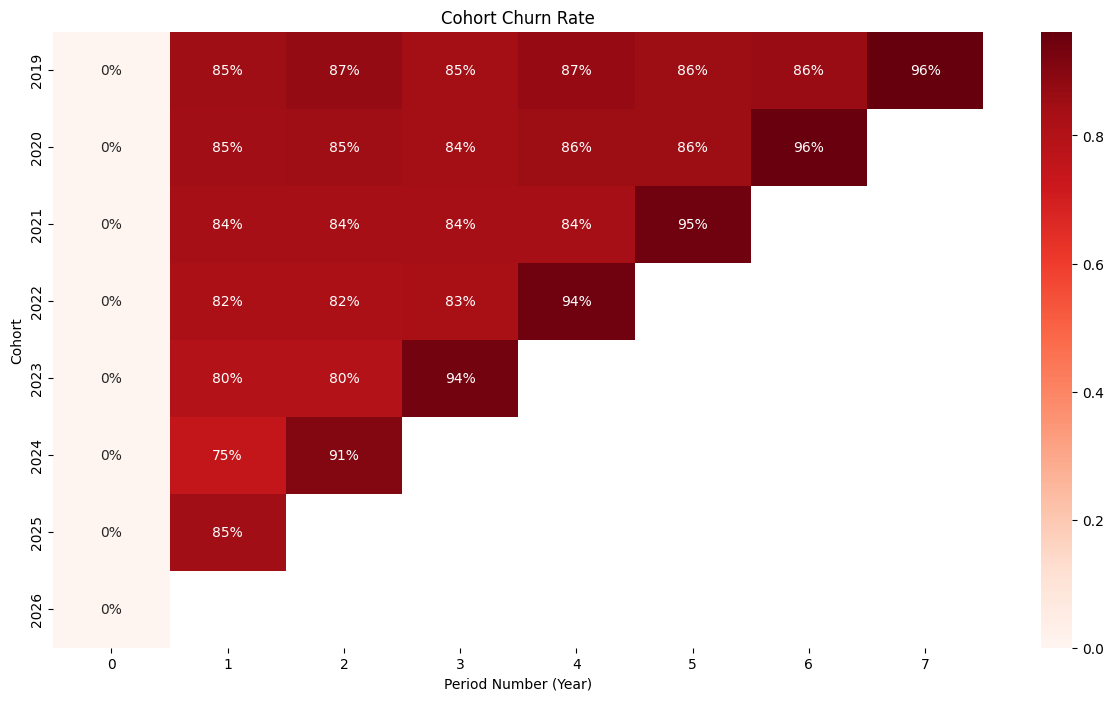

In [21]:
# Calculate churn matrix (1 - retention_matrix)
churn_matrix = 1 - retention_matrix

plt.figure(figsize=(15, 8))
sns.heatmap(churn_matrix, annot=True, fmt='.0%', cmap='Reds')
plt.title('Cohort Churn Rate')
plt.xlabel('Period Number (Year)')
plt.ylabel('Cohort')
plt.show()

### Churn Rate per Cohort (Monthly per Year)


--- Cohort Churn Analysis for Year: 2019 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


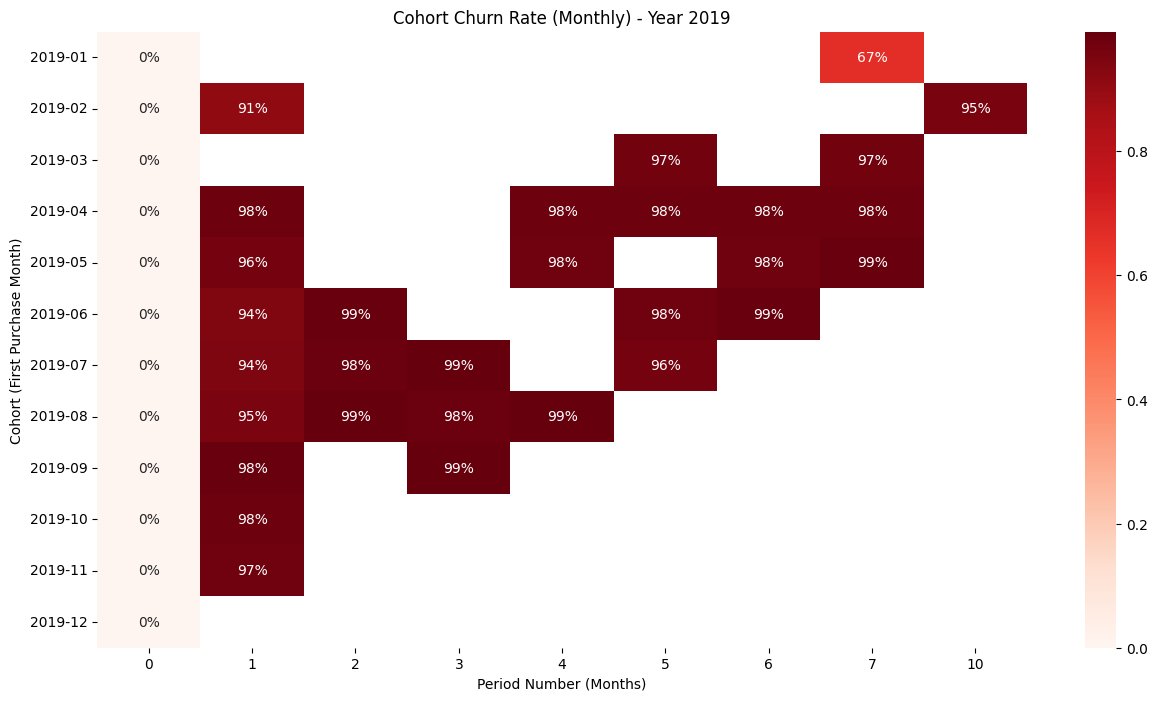


--- Cohort Churn Analysis for Year: 2020 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


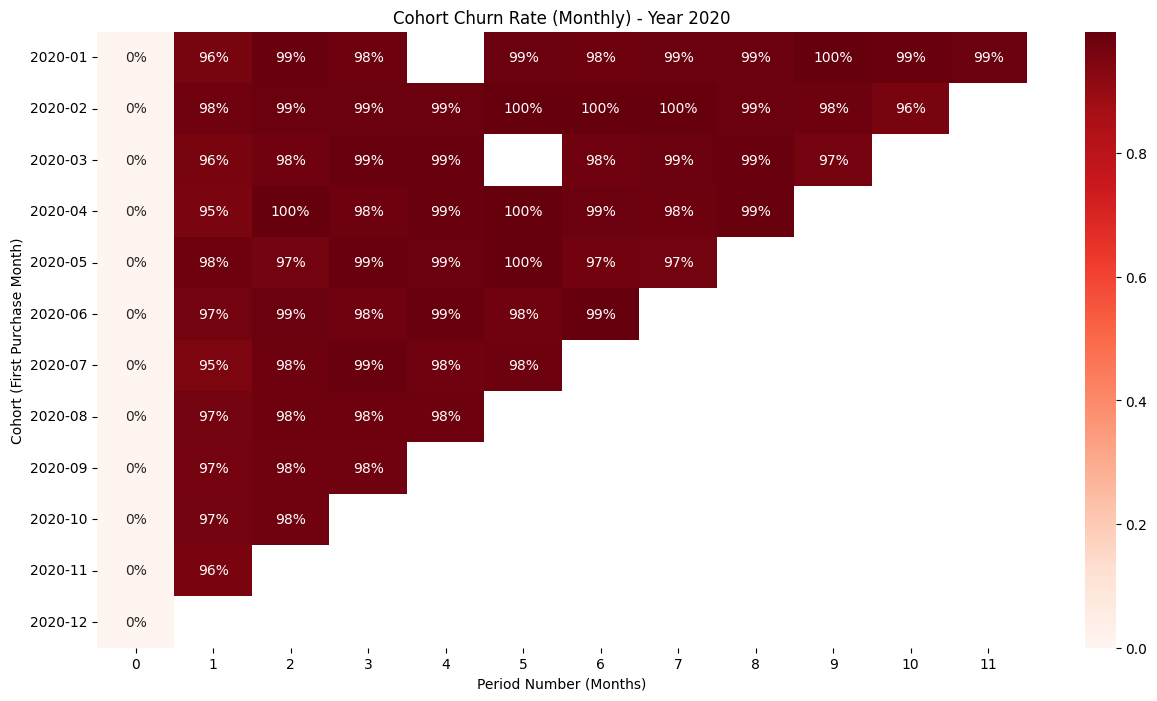


--- Cohort Churn Analysis for Year: 2021 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


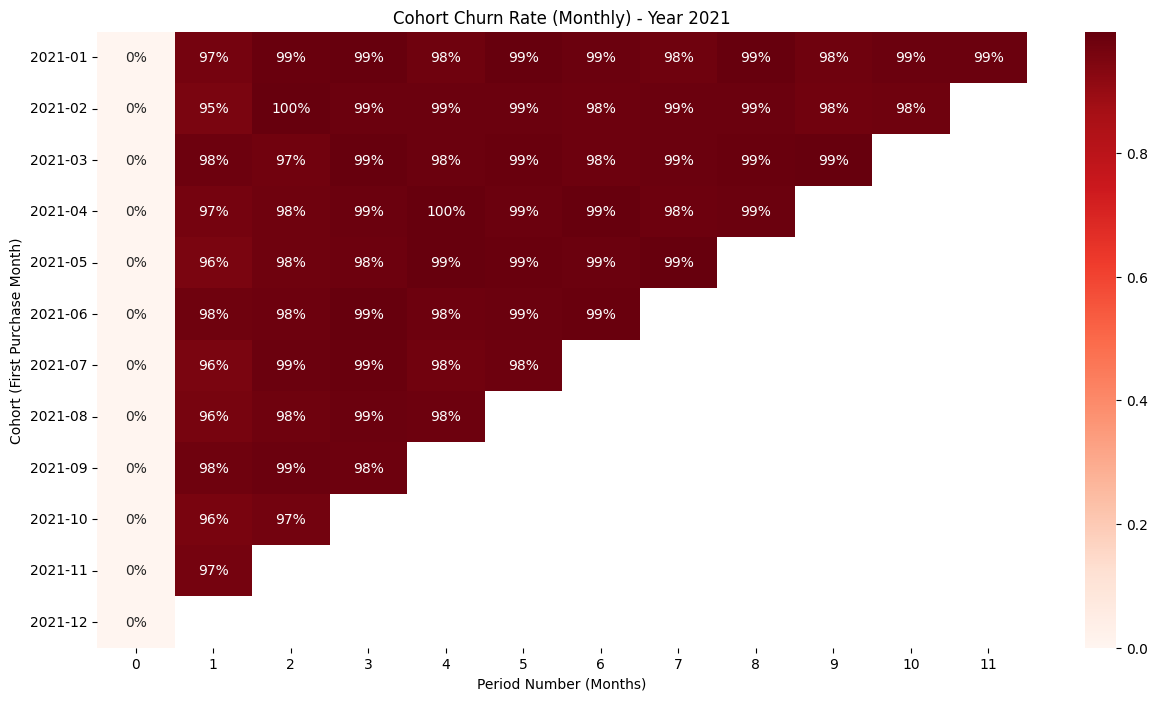


--- Cohort Churn Analysis for Year: 2022 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


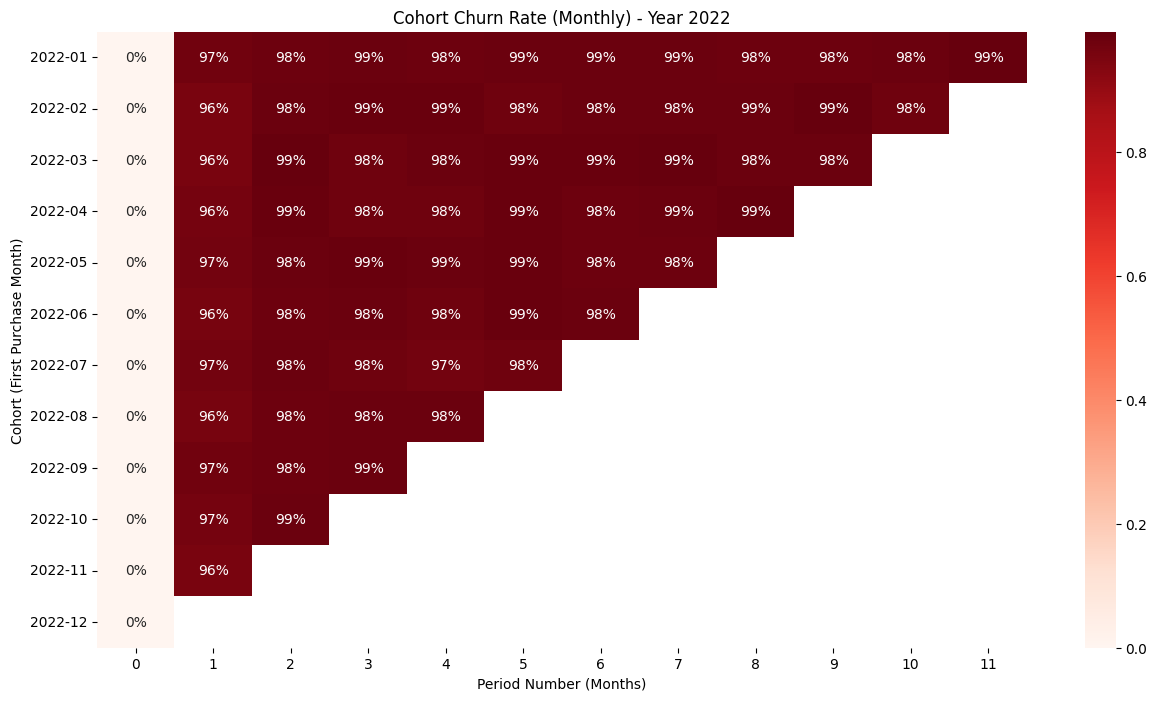


--- Cohort Churn Analysis for Year: 2023 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


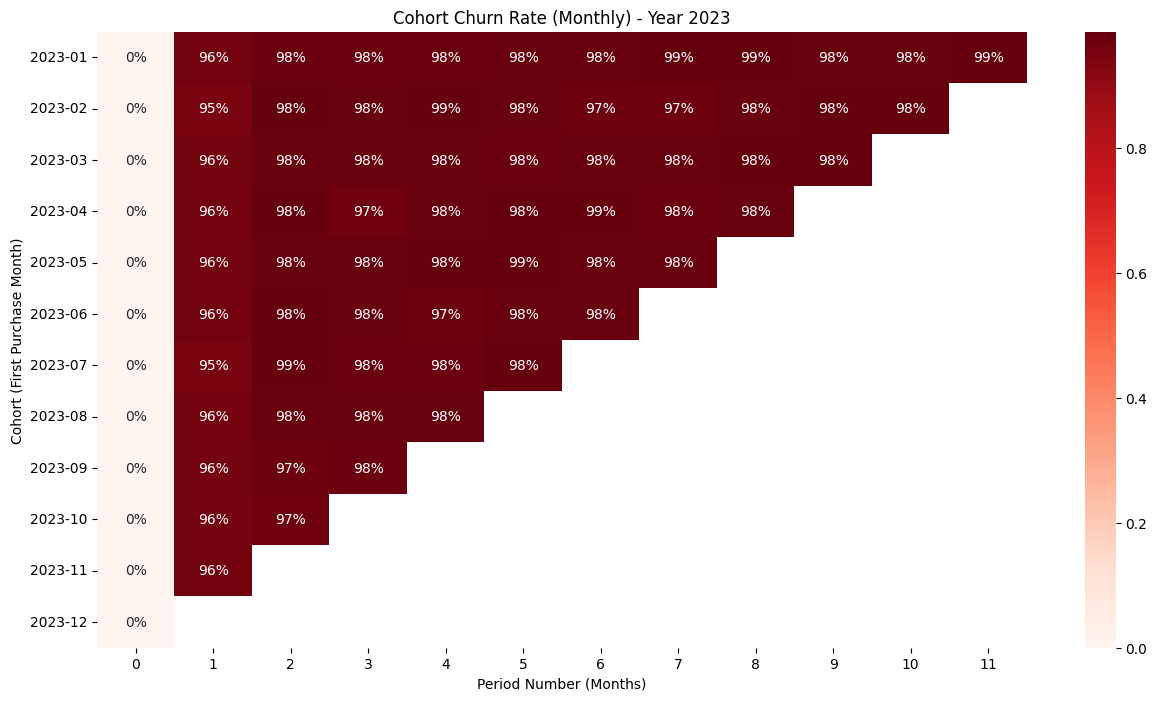


--- Cohort Churn Analysis for Year: 2024 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


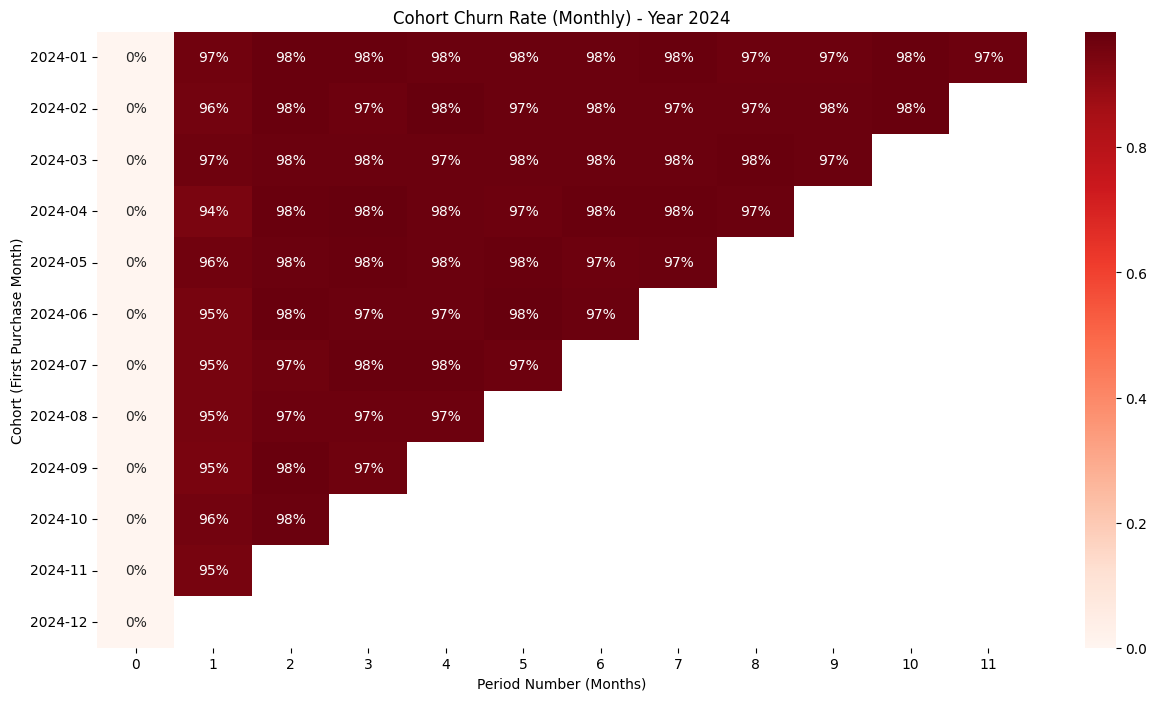


--- Cohort Churn Analysis for Year: 2025 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


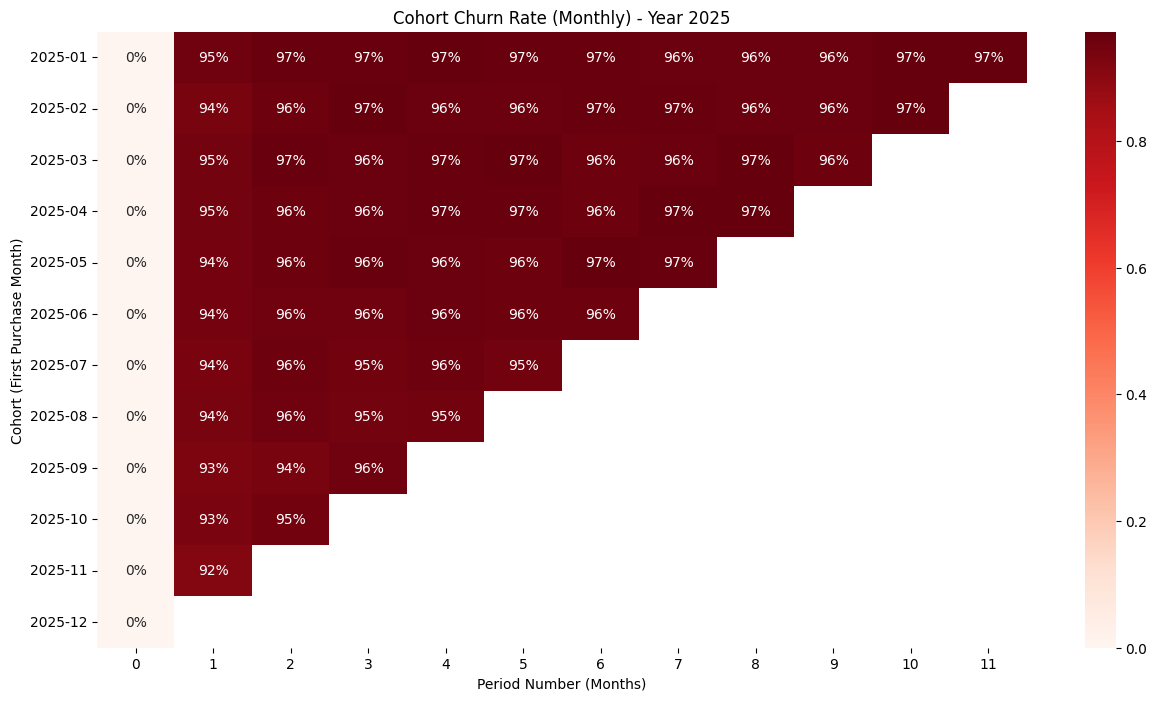


--- Cohort Churn Analysis for Year: 2026 ---


/tmp/ipykernel_1686/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


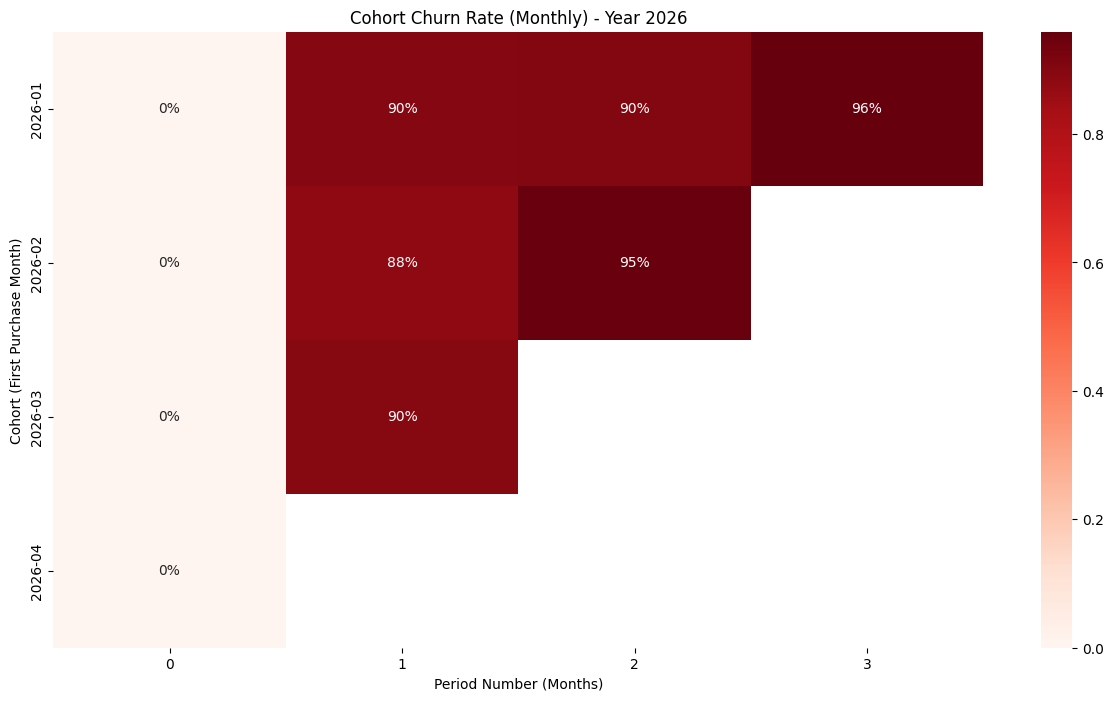

In [22]:
for year in all_years:
    print(f"\n--- Cohort Churn Analysis for Year: {year} ---")

    df_year = df[df['created_at'].dt.year == year].copy()

    if df_year.empty:
        print(f"No data for year {year}, skipping.")
        continue

    df_year['order_month'] = df_year['created_at'].dt.to_period('M')
    df_year['cohort'] = df_year.groupby('user_id')['order_month'].transform('min')

    cohort_data_yearly = df_year.groupby(['cohort', 'order_month'])['user_id'].nunique().reset_index()

    cohort_data_yearly['period_number'] = (cohort_data_yearly.order_month - cohort_data_yearly.cohort).apply(lambda x: x.n)

    cohort_pivot_yearly = cohort_data_yearly.pivot_table(index='cohort', columns='period_number', values='user_id')

    cohort_sizes_yearly = cohort_pivot_yearly.iloc[:,0]
    retention_matrix_yearly = cohort_pivot_yearly.divide(cohort_sizes_yearly, axis=0)

    # Calculate churn matrix for the yearly-monthly analysis
    churn_matrix_yearly = 1 - retention_matrix_yearly

    plt.figure(figsize=(15, 8))
    sns.heatmap(churn_matrix_yearly, annot=True, fmt='.0%', cmap='Reds')
    plt.title(f'Cohort Churn Rate (Monthly) - Year {year}')
    plt.xlabel('Period Number (Months)')
    plt.ylabel('Cohort (First Purchase Month)')
    plt.show()

##Churn Indication

In [23]:
last_purchase = df.groupby('user_id')['created_at'].max()
inactive_users = last_purchase[last_purchase < (snapshot_date - pd.Timedelta(days=90))]

In [24]:
inactive_users

,created_at
user_id,
1,2025-12-23 13:46:20+00:00
2,2025-08-24 05:50:31+00:00
4,2024-09-03 01:44:38+00:00
9,2025-06-30 03:24:13+00:00
10,2025-09-24 21:28:48+00:00
...,...
99994,2023-03-14 13:30:39+00:00
99996,2025-11-30 12:57:04+00:00
99997,2025-06-14 20:41:35+00:00


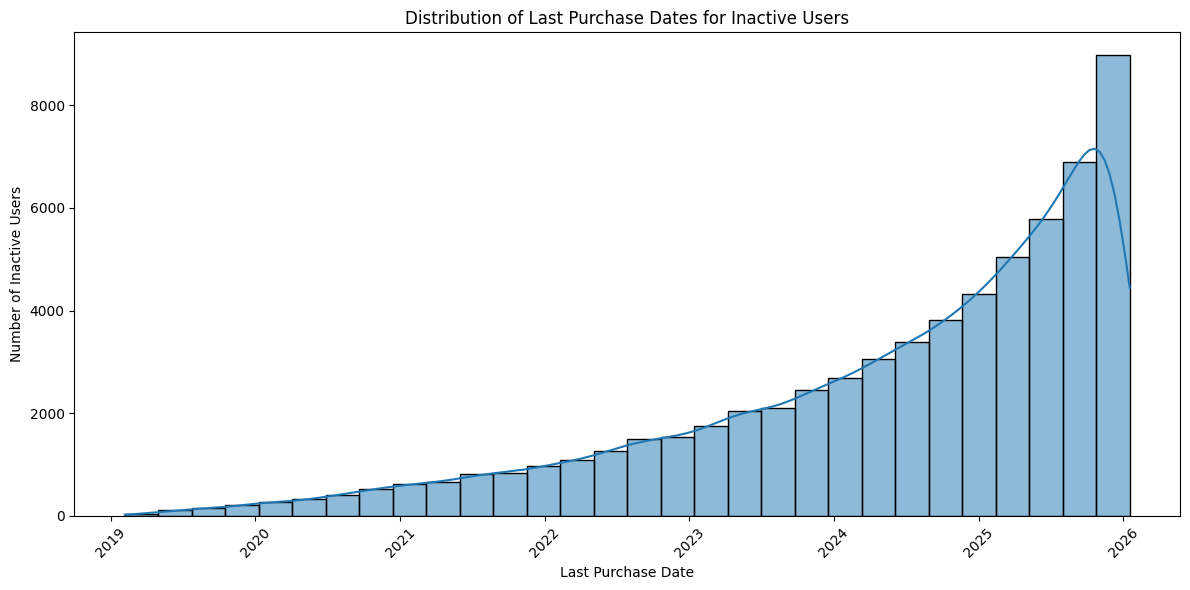

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(inactive_users, kde=True, bins=30)
plt.title('Distribution of Last Purchase Dates for Inactive Users')
plt.xlabel('Last Purchase Date')
plt.ylabel('Number of Inactive Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Jumlah inactive users meningkat signifikan di periode terbaru (2024–2026) → menunjukkan banyak customer yang baru churn
* Distribusi condong ke kanan → sebagian besar user berhenti relatif baru-baru ini, bukan sejak lama
* Ini mengindikasikan bahwa churn bukan hanya masalah lama, tapi masih terus terjadi hingga sekarang
* Lonjakan di akhir periode bisa berarti:
  * Banyak user baru yang tidak kembali setelah pembelian pertama
  * Atau retention strategy belum efektif dalam jangka pendek

###Calculate the percentage of inactive users by cohort year

Percentage of Inactive Users by Cohort Year:
cohort_year
2019    96.947271
2020    96.366237
2021    95.522139
2022    95.371025
2023    94.662681
2024    92.298754
2025    86.859120
2026     8.449992
Freq: Y-DEC, Name: count, dtype: float64


/tmp/ipykernel_1686/1777175759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentage_inactive_by_cohort.index.astype(str), y=percentage_inactive_by_cohort.values, palette='viridis')


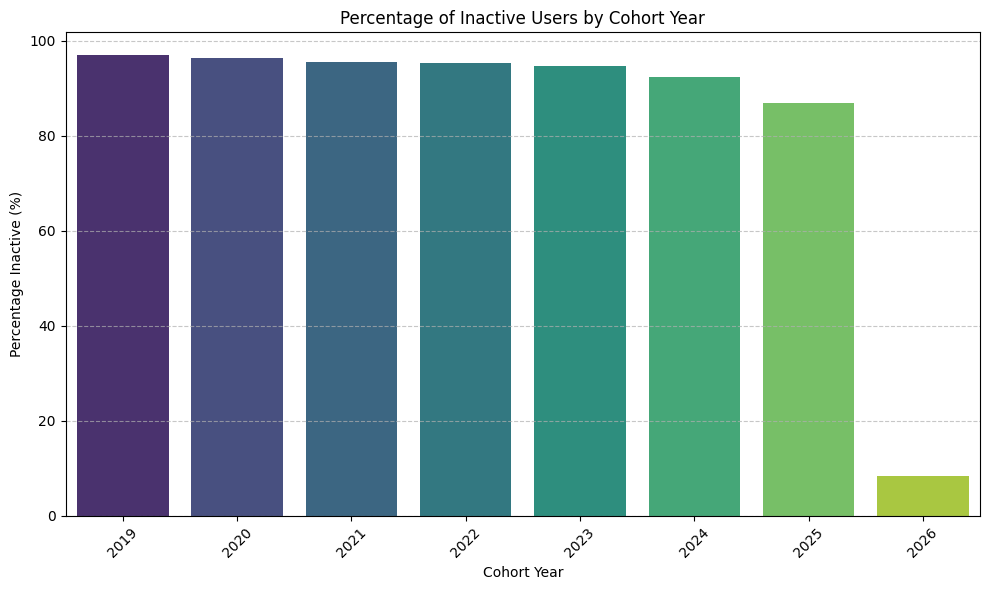

In [26]:
import pandas as pd

# Get the cohort year for each user (first purchase year)
user_cohort = df.groupby('user_id')['cohort'].first().rename('cohort_year')

# Convert inactive_users Series to a DataFrame for easier merging
inactive_users_df = inactive_users.reset_index()
inactive_users_df = inactive_users_df.rename(columns={'created_at': 'last_purchase_date'})

# Merge with user_cohort to get the cohort year of inactive users
inactive_users_with_cohort = inactive_users_df.merge(user_cohort, on='user_id', how='left')

# Count total users per cohort
total_users_per_cohort = user_cohort.value_counts().sort_index()

# Count inactive users per cohort
inactive_users_per_cohort = inactive_users_with_cohort['cohort_year'].value_counts().sort_index()

# Calculate percentage of inactive users per cohort
percentage_inactive_by_cohort = (inactive_users_per_cohort / total_users_per_cohort * 100).fillna(0)

print("Percentage of Inactive Users by Cohort Year:")
print(percentage_inactive_by_cohort)

# Visualize the percentage
plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_inactive_by_cohort.index.astype(str), y=percentage_inactive_by_cohort.values, palette='viridis')
plt.title('Percentage of Inactive Users by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Percentage Inactive (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* Hampir semua cohort (2019–2024) memiliki inactive rate sangat tinggi (>90%) → menunjukkan retention jangka panjang sangat rendah
* Ada sedikit perbaikan di cohort yang lebih baru:
    * 2019: 97% inactive
    * 2024: 92% inactive
    * indikasi retention mulai membaik, tapi masih belum signifikan
* Cohort 2025 turun ke ~86% inactive → bisa jadi tanda awal improvement retention, tapi tetap mayoritas customer tidak bertahan
* Cohort 2026 sangat rendah (6%) → jelas bias karena data belum mature, belum bisa dijadikan acuan

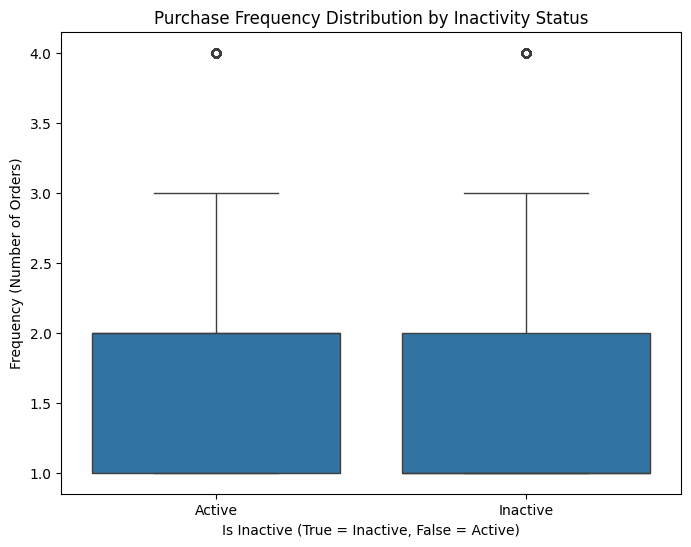

In [27]:
rfm['is_inactive'] = rfm.index.isin(inactive_users.index)

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_inactive', y='frequency', data=rfm)
plt.title('Purchase Frequency Distribution by Inactivity Status')
plt.xlabel('Is Inactive (True = Inactive, False = Active)')
plt.ylabel('Frequency (Number of Orders)')
plt.xticks([0, 1], ['Active', 'Inactive'])
plt.show()

* Distribusi frequency antara active vs inactive hampir identik → mayoritas customer di kedua grup hanya melakukan 1–2 transaksi
* Median di kedua kelompok sama (~1) → menunjukkan bahwa single purchase behavior sangat dominan
* Bahkan customer yang inactive tidak jauh berbeda dari active dalam hal jumlah transaksi → artinya frekuensi pembelian bukan pembeda utama churn
* Ada sedikit outlier (3–4 transaksi), tapi jumlahnya kecil → hanya sebagian kecil customer yang benar-benar engaged

In [28]:
mean_frequency_by_status = rfm.groupby('is_inactive')['frequency'].mean()
print("Average Purchase Frequency by Inactivity Status:")
print(mean_frequency_by_status)

Average Purchase Frequency by Inactivity Status:
is_inactive
False    1.818570
True     1.500903
Name: frequency, dtype: float64


* Customer active (False) punya rata-rata transaksi 1.8x
* Customer inactive (True) hanya 1.5x

👉 Artinya:

Customer yang akhirnya tetap aktif cenderung melakukan lebih banyak pembelian, tapi selisihnya tidak terlalu besar (0.3 transaksi)

#ML Project Extension [Predicting Customer Churn Using Machine Learning]
Membangun model machine learning untuk memprediksi kemungkinan customer akan berhenti bertransaksi (churn), sehingga bisnis dapat melakukan tindakan preventif.

##Definisi Churn

In [29]:
df

,order_id,user_id,product_id,sale_price,created_at,country,name,month,order_year,cohort
0,21265,16855,13659,1.82,2025-09-18 01:48:11+00:00,Poland,Blank Long Cuff Beanie Cap (Choose Many Colors...,2025-09,2025,2024
1,79608,63382,12580,3.37,2026-04-13 16:11:45.821310+00:00,Poland,Allegra K 5 Pcs Bra Black 2x3 Hooks Extenders ...,2026-04,2026,2026
2,56557,45013,13943,3.40,2021-11-20 18:07:11+00:00,Poland,Blues Brothers Wayfarer Dark Black Sun Glasses...,2021-11,2021,2021
3,50333,39939,28406,3.46,2026-03-15 05:03:20+00:00,Poland,Extra Warm Metro Fleece Ear Warmers,2026-03,2026,2025
4,58363,46422,28406,3.46,2026-04-15 12:10:24.301882+00:00,Poland,Extra Warm Metro Fleece Ear Warmers,2026-04,2026,2026
...,...,...,...,...,...,...,...,...,...,...
181774,106666,85059,24341,950.00,2025-10-29 05:17:26+00:00,United States,Nobis Yatesy Parka,2025-10,2025,2025
181775,107118,85444,24110,990.00,2026-01-26 00:01:33+00:00,United States,Woolrich Arctic Parka DF,2026-01,2026,2026
181776,36738,29199,24447,999.00,2025-02-02 04:46:23+00:00,United States,Darla,2025-02,2025,2023
181777,35543,28215,23546,999.00,2024-04-04 15:40:41+00:00,United States,Alpha Industries Rip Stop Short,2024-04,2024,2024


In [30]:
df['last_purchase'] = df.groupby('user_id')['created_at'].transform('max')

snapshot_date = df['created_at'].max()

df['churn'] = (snapshot_date - df['last_purchase']).dt.days > 90

/tmp/ipykernel_1686/3503995083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['last_purchase'] = df.groupby('user_id')['created_at'].transform('max')
/tmp/ipykernel_1686/3503995083.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['churn'] = (snapshot_date - df['last_purchase']).dt.days > 90


##Feature Engineering

In [31]:
rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

In [32]:
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

##Prepare Data

In [33]:
import datetime as dt
from sklearn.model_selection import train_test_split

# Ensure snapshot_date is available
snapshot_date = df['created_at'].max()

# 1. Recalculate RFM from a clean state to prevent merge errors
rfm_clean = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})
rfm_clean.columns = ['recency', 'frequency', 'monetary']

# 2. Calculate avg_order_value
rfm_clean['avg_order_value'] = rfm_clean['monetary'] / rfm_clean['frequency']

# Get the churn status for each user from the original df
# This 'churn' column is derived from `df['churn']` created earlier.
user_churn_status = df.groupby('user_id')['churn'].first()

# 3. Add the churn status to the rfm DataFrame
# Since 'rfm_clean' does not have a 'churn' column, this merge will add a single 'churn' column without suffixes.
rfm = rfm_clean.merge(user_churn_status, on='user_id', how='left')

# 'recency' is explicitly removed from features to prevent data leakage in churn prediction.
# The 'churn' column is the target variable and MUST be removed from the feature set 'X'.
X = rfm.drop(columns=['recency', 'churn'], errors='raise') # Drop recency and the 'churn' column from features
y = rfm['churn'] # 'churn' is the correct target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Retrain the model with the updated X_train and y_train
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model Evaluation (after addressing data leakage and removing 'recency'):")
print(classification_report(y_test, y_pred))

# Display feature importances again
importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importances (after addressing data leakage):")
print(importance.sort_values(ascending=False))

Model Evaluation (after addressing data leakage and removing 'recency'):
              precision    recall  f1-score   support

       False       0.25      0.15      0.19      3246
        True       0.80      0.89      0.84     12769

    accuracy                           0.74     16015
   macro avg       0.53      0.52      0.52     16015
weighted avg       0.69      0.74      0.71     16015


Feature Importances (after addressing data leakage):
monetary           0.486231
avg_order_value    0.484586
frequency          0.029182
dtype: float64


Model yang dibangun menunjukkan performa yang cukup baik secara keseluruhan dengan accuracy sebesar 74%, namun metrik ini cenderung bias karena distribusi data yang tidak seimbang, di mana jumlah customer inactive jauh lebih besar dibanding active. Hal ini terlihat dari perbedaan performa antar kelas.

Model mampu mengidentifikasi customer yang inactive dengan sangat baik, ditunjukkan oleh recall sebesar 0.89 dan precision sebesar 0.80. Artinya, sebagian besar customer yang benar-benar churn berhasil terdeteksi oleh model. Namun, performa model dalam mengidentifikasi customer yang masih aktif tergolong rendah, dengan recall hanya 0.15 dan precision 0.25. Ini menunjukkan bahwa banyak customer aktif yang salah diklasifikasikan sebagai inactive.

Perbedaan ini mengindikasikan bahwa model cenderung lebih “sensitif” terhadap pola churn, tetapi kurang mampu membedakan karakteristik customer yang tetap aktif. Nilai macro average yang relatif rendah (~0.52) juga menegaskan bahwa performa model tidak seimbang di kedua kelas, meskipun weighted average terlihat lebih tinggi karena dominasi kelas inactive.

Dari sisi feature importance, terlihat bahwa faktor yang paling berpengaruh dalam prediksi adalah monetary dan average order value (AOV), masing-masing berkontribusi hampir 50%. Sementara itu, frequency hanya memiliki pengaruh yang sangat kecil. Hal ini menunjukkan bahwa nilai transaksi customer jauh lebih menentukan dalam memprediksi churn dibandingkan seberapa sering mereka bertransaksi.

---

Secara keseluruhan, model ini sudah cukup efektif untuk mendeteksi potensi churn, namun masih perlu perbaikan untuk meningkatkan kemampuannya dalam mengidentifikasi customer yang tetap aktif. Insight ini juga konsisten dengan hasil analisis sebelumnya, di mana sebagian besar customer memiliki frekuensi pembelian yang rendah dan engagement yang terbatas, sehingga sulit dibedakan hanya berdasarkan jumlah transaksi.

##Model Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##Evaluation

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.25      0.15      0.19      3246
        True       0.80      0.89      0.84     12769

    accuracy                           0.74     16015
   macro avg       0.53      0.52      0.52     16015
weighted avg       0.69      0.74      0.71     16015



In [37]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
monetary,0.488734
avg_order_value,0.484178
frequency,0.027088


Hasil feature importance menunjukkan bahwa model sangat bergantung pada dua variabel utama, yaitu monetary dan average order value (AOV), yang masing-masing memiliki kontribusi hampir 50% terhadap prediksi. Sementara itu, frequency hanya berkontribusi sekitar 2–3%, sehingga pengaruhnya relatif kecil dalam menentukan apakah seorang customer akan churn atau tetap aktif.

Hal ini mengindikasikan bahwa nilai transaksi customer (berapa banyak mereka membelanjakan uang) jauh lebih penting dibandingkan seberapa sering mereka bertransaksi. Dengan kata lain, customer dengan total spending tinggi atau nilai pembelian yang besar cenderung lebih mudah dikenali oleh model sebagai customer yang tidak churn.

Di sisi lain, rendahnya kontribusi frequency menunjukkan bahwa jumlah transaksi belum cukup kuat untuk membedakan perilaku customer. Ini sejalan dengan analisis sebelumnya, di mana sebagian besar customer—baik yang aktif maupun inactive—memiliki jumlah transaksi yang relatif rendah (1–2 kali), sehingga variabel ini kurang informatif bagi model.

Secara keseluruhan, insight ini menegaskan bahwa customer value (monetary & AOV) adalah faktor kunci dalam memprediksi churn, sementara frequency belum menjadi pembeda utama, kemungkinan karena rendahnya tingkat engagement secara umum di seluruh customer base.

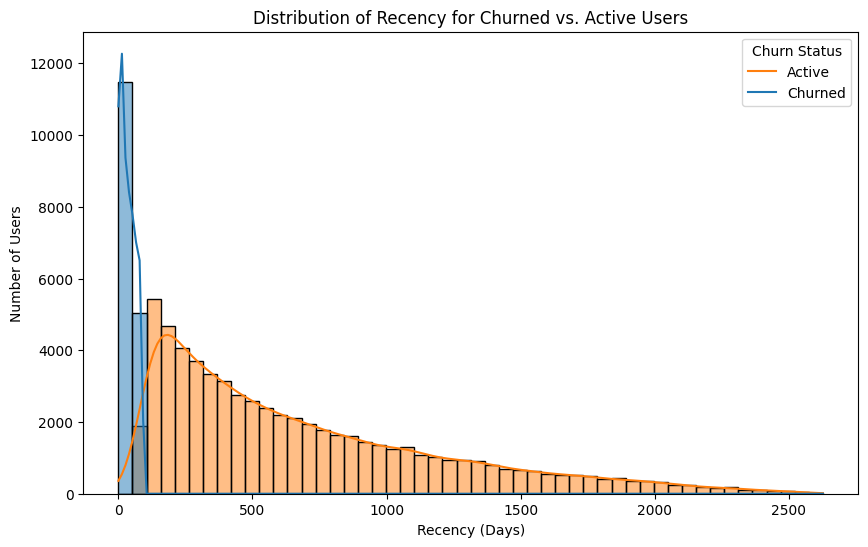

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=rfm, x='recency', hue='churn', kde=True, bins=50)
plt.title('Distribution of Recency for Churned vs. Active Users')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Users')
plt.legend(title='Churn Status', labels=['Active', 'Churned'])
plt.show()

Visualisasi ini menunjukkan perbedaan distribusi recency antara customer yang churn dan yang masih aktif. Terlihat bahwa customer yang churn cenderung terkonsentrasi pada nilai recency yang rendah, yang berarti mereka berhenti bertransaksi tidak lama setelah pembelian terakhir. Sebaliknya, customer yang masih aktif memiliki distribusi recency yang lebih panjang, menandakan mereka tetap melakukan transaksi dalam rentang waktu yang lebih berkelanjutan.

Temuan ini memperkuat insight sebelumnya bahwa sebagian besar customer memiliki tingkat engagement yang rendah dan tidak melakukan repeat purchase dalam waktu dekat. Dengan kata lain, banyak customer yang hanya melakukan satu kali transaksi lalu tidak kembali dalam periode singkat, sehingga akhirnya masuk kategori churn.

Selain itu, distribusi ini menunjukkan bahwa recency merupakan indikator yang sangat kuat dalam mengidentifikasi churn, karena semakin lama customer tidak bertransaksi, semakin besar kemungkinan mereka menjadi inactive. Oleh karena itu, periode awal setelah pembelian pertama menjadi fase yang sangat krusial untuk intervensi, seperti strategi retensi atau engagement, guna mencegah customer cepat churn.



---



# SUMMARY

* Tren Pendapatan: Pendapatan menunjukkan tren naik yang konsisten tanpa penurunan signifikan, dengan akselerasi pertumbuhan di periode akhir. Ini mengindikasikan bisnis yang relatif stabil dengan potensi pertumbuhan lebih lanjut.

* Kontribusi Produk: Pendapatan didominasi oleh produk premium (misalnya, outerwear dari merek besar). Pola ini menunjukkan model bisnis high-value, low-volume, di mana harga tinggi menjadi pendorong utama pendapatan. Produk dengan pendapatan terendah (worst products) memiliki kontribusi yang sangat kecil, mengindikasikan distribusi long-tail di mana sebagian kecil produk menyumbang mayoritas pendapatan.

* Analisis Nilai Pelanggan (Customer Value): Distribusi nilai transaksi sangat condong ke kanan (right-skewed), artinya mayoritas transaksi bernilai rendah, tetapi ada sejumlah kecil transaksi bernilai sangat tinggi yang signifikan. Median nilai transaksi jauh lebih rendah dari mean, menegaskan peran penting outlier high-value dalam menaikkan rata-rata. Sebagian besar pelanggan berada di segmen belanja rendah-menengah, namun pendapatan sangat dipengaruhi oleh segmen premium.

* Analisis RFM (Recency, Frequency, Monetary):

  * Recency: Banyak pelanggan sudah lama tidak bertransaksi, menunjukkan potensi churn yang tinggi atau penurunan engagement.
  * Frequency: Mayoritas pelanggan hanya melakukan 1-2 transaksi, menandakan tingkat pembelian ulang yang rendah.
  * Monetary: Distribusi sangat skewed, sebagian besar pelanggan berbelanja dalam jumlah kecil, dengan hanya sedikit yang memiliki nilai tinggi. Secara keseluruhan, basis pelanggan didominasi oleh low engagement (jarang membeli & sudah lama tidak aktif), dengan pendapatan yang ditopang oleh segelintir pelanggan yang sering dan berbelanja besar.

* Analisis Kohort (Cohort Analysis):
  * Retensi Tahunan: Tingkat retensi menurun drastis setelah periode pertama (~15-26% di tahun berikutnya) dan terus menurun hingga <10% di tahun-tahun berikutnya. Ini menunjukkan drop-off yang tinggi setelah pembelian awal dan masalah struktural dalam retensi.
  * Tingkat Churn Tahunan: Hampir semua kohort (2019–2024) memiliki inactive rate yang sangat tinggi (>90%), menunjukkan retensi jangka panjang yang sangat rendah. Meskipun ada sedikit perbaikan di kohort yang lebih baru, mayoritas pelanggan tidak bertahan.
* Indikasi Churn:
  * Jumlah pengguna tidak aktif (inactive users) meningkat signifikan di periode terbaru (2024–2026), menunjukkan bahwa churn adalah masalah yang terus berlanjut. Distribusi recency untuk pengguna tidak aktif menunjukkan bahwa sebagian besar dari mereka berhenti bertransaksi relatif baru-baru ini.
  * Perbandingan frekuensi pembelian antara pengguna aktif dan tidak aktif menunjukkan bahwa frekuensi pembelian (frequency) bukan pembeda utama dalam churn, karena sebagian besar di kedua kelompok hanya melakukan 1-2 transaksi. Rata-rata transaksi pelanggan aktif hanya sedikit lebih tinggi (1.8x) dibandingkan pelanggan tidak aktif (1.5x).

## Prediksi Churn dengan Machine Learning (Model Random Forest):

Model menunjukkan akurasi 74%, namun metrik ini bias karena data yang tidak seimbang. Model sangat baik dalam mengidentifikasi pelanggan yang tidak aktif (recall 0.89, precision 0.80) tetapi lemah dalam mengidentifikasi pelanggan aktif (recall 0.15, precision 0.25). Ini berarti model cenderung sensitif terhadap pola churn tetapi kurang mampu membedakan pelanggan yang tetap aktif.

Feature Importance: Faktor terpenting dalam prediksi churn adalah monetary (jumlah total pembelian) dan average order value (AOV), yang masing-masing berkontribusi hampir 50%. Sementara itu, frequency hanya memiliki kontribusi sangat kecil (sekitar 2-3%). Ini menunjukkan bahwa nilai transaksi pelanggan jauh lebih menentukan dalam memprediksi churn dibandingkan seberapa sering mereka bertransaksi.

Kesimpulan: Model ini cukup efektif untuk mendeteksi potensi churn, tetapi perlu perbaikan untuk mengidentifikasi pelanggan aktif. Monetary value adalah kunci dalam memprediksi churn, sejalan dengan temuan bahwa sebagian besar pelanggan memiliki frekuensi pembelian yang rendah dan engagement yang terbatas.